In [1]:
# CELL 1: IMPORT LIBRARIES AND SETUP
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from scipy.sparse.linalg import svds
import warnings
import os

warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [2]:
# ============================================
# CELL 2: LOAD MOVIELENS DATASET
# ============================================

def load_movielens_data():
    """
    Load MovieLens 100K dataset
    Update the path to match your file location
    """
    
    ratings_path = r"D:\Elevvo_ML\dataset of task5\ml-100k\u.data"
    movies_path = r"D:\Elevvo_ML\dataset of task5\ml-100k\u.item"
    
    # Check if files exist
    if not os.path.exists(ratings_path):
        print(f" Error: Ratings file not found at {ratings_path}")
        print("Please update the path in the code above")
        return None, None
    
    if not os.path.exists(movies_path):
        print(f" Error: Movies file not found at {movies_path}")
        print("Please update the path in the code above")
        return None, None
    
    # Load ratings data
    print("Loading ratings data...")
    ratings = pd.read_csv(ratings_path, sep='\t', 
                          names=['user_id', 'movie_id', 'rating', 'timestamp'])
    
    # Load movie information
    print("Loading movies data...")
    movies = pd.read_csv(movies_path, sep='|', encoding='latin-1',
                         names=['movie_id', 'title', 'release_date', 'video_release_date',
                                'imdb_url'] + [f'genre_{i}' for i in range(19)], 
                         usecols=[0, 1, 2, 3, 4])
    
    return ratings, movies

In [3]:
# CELL 3: EXECUTE DATA LOADING


# Load the data
ratings, movies = load_movielens_data()

# Check if data loaded successfully
if ratings is not None and movies is not None:
    print("\n" + "="*50)
    print("DATASET LOADED")
    print("="*50)
    print(f"Ratings dataset shape: {ratings.shape}")
    print(f"Movies dataset shape: {movies.shape}")
    print(f"\nNumber of unique users: {ratings['user_id'].nunique():,}")
    print(f"Number of unique movies: {ratings['movie_id'].nunique():,}")
    print(f"Number of ratings: {len(ratings):,}")
    print(f"Rating range: {ratings['rating'].min()} to {ratings['rating'].max()}")
    
    print("\n" + "="*50)
    print("FIRST 5 ROWS OF RATINGS DATA:")
    print("="*50)
    print(ratings.head())
    
    print("\n" + "="*50)
    print("FIRST 5 ROWS OF MOVIES DATA:")
    print("="*50)
    print(movies.head())
else:
    print(" Failed to load data.")

Loading ratings data...
Loading movies data...

DATASET LOADED
Ratings dataset shape: (100000, 4)
Movies dataset shape: (1682, 5)

Number of unique users: 943
Number of unique movies: 1,682
Number of ratings: 100,000
Rating range: 1 to 5

FIRST 5 ROWS OF RATINGS DATA:
   user_id  movie_id  rating  timestamp
0      196       242       3  881250949
1      186       302       3  891717742
2       22       377       1  878887116
3      244        51       2  880606923
4      166       346       1  886397596

FIRST 5 ROWS OF MOVIES DATA:
   movie_id              title release_date  video_release_date  \
0         1   Toy Story (1995)  01-Jan-1995                 NaN   
1         2   GoldenEye (1995)  01-Jan-1995                 NaN   
2         3  Four Rooms (1995)  01-Jan-1995                 NaN   
3         4  Get Shorty (1995)  01-Jan-1995                 NaN   
4         5     Copycat (1995)  01-Jan-1995                 NaN   

                                            imdb_url  
0  

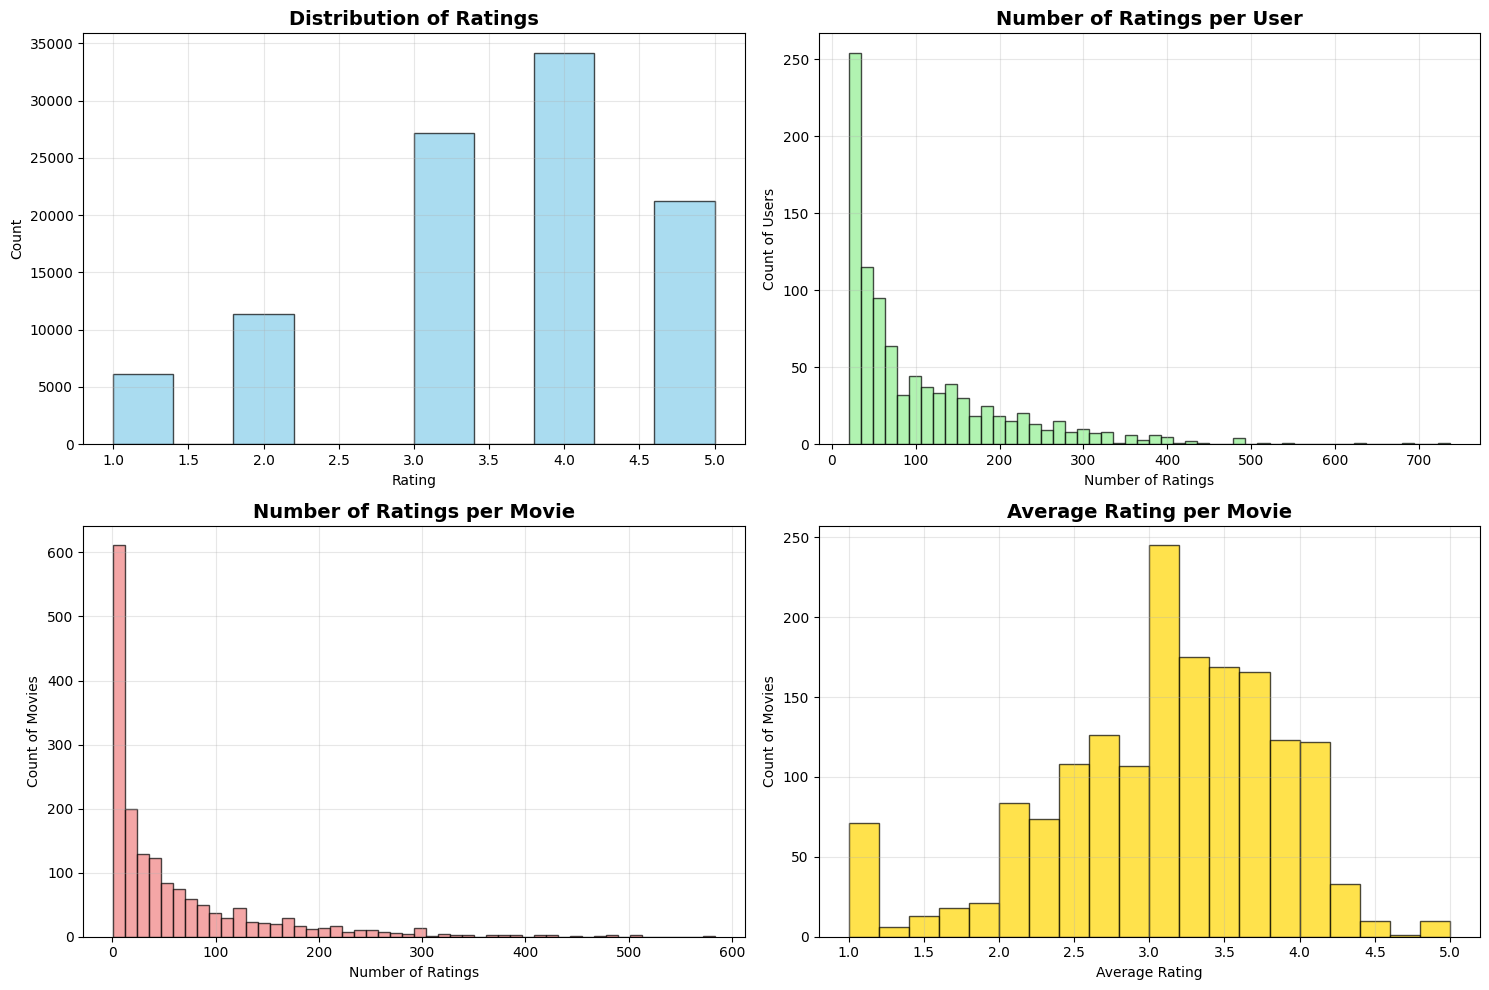


SUMMARY STATISTICS
Total ratings: 100,000
Average rating: 3.53
Rating std deviation: 1.13
Median rating: 4.00

Matrix sparsity: 0.9370 (93.70% of matrix is empty)

Most active user rated: 737 movies
Least active user rated: 20 movies

Most rated movie has: 583 ratings
Least rated movie has: 1 ratings


In [4]:
# CELL 4: EXPLORATORY DATA ANALYSIS (EDA)

def explore_data(ratings, movies):
    """
    Perform basic visualization to understand the dataset
    """
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. Distribution of ratings
    axes[0, 0].hist(ratings['rating'], bins=10, edgecolor='black', alpha=0.7, color='skyblue')
    axes[0, 0].set_title('Distribution of Ratings', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Rating')
    axes[0, 0].set_ylabel('Count')
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Ratings per user
    user_rating_counts = ratings.groupby('user_id')['rating'].count()
    axes[0, 1].hist(user_rating_counts, bins=50, edgecolor='black', alpha=0.7, color='lightgreen')
    axes[0, 1].set_title('Number of Ratings per User', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Number of Ratings')
    axes[0, 1].set_ylabel('Count of Users')
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Ratings per movie
    movie_rating_counts = ratings.groupby('movie_id')['rating'].count()
    axes[1, 0].hist(movie_rating_counts, bins=50, edgecolor='black', alpha=0.7, color='lightcoral')
    axes[1, 0].set_title('Number of Ratings per Movie', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Number of Ratings')
    axes[1, 0].set_ylabel('Count of Movies')
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Average rating per movie
    movie_avg_ratings = ratings.groupby('movie_id')['rating'].mean()
    axes[1, 1].hist(movie_avg_ratings, bins=20, edgecolor='black', alpha=0.7, color='gold')
    axes[1, 1].set_title('Average Rating per Movie', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Average Rating')
    axes[1, 1].set_ylabel('Count of Movies')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\n" + "="*50)  
    print("SUMMARY STATISTICS")
    print("="*50) 
    print(f"Total ratings: {len(ratings):,}")
    print(f"Average rating: {ratings['rating'].mean():.2f}")
    print(f"Rating std deviation: {ratings['rating'].std():.2f}")
    print(f"Median rating: {ratings['rating'].median():.2f}")
    
    # Calculate sparsity
    n_users = ratings['user_id'].nunique()
    n_movies = ratings['movie_id'].nunique()
    total_possible = n_users * n_movies
    sparsity = 1 - (len(ratings) / total_possible)
    print(f"\nMatrix sparsity: {sparsity:.4f} ({sparsity*100:.2f}% of matrix is empty)")
    
    # Most active users
    print(f"\nMost active user rated: {user_rating_counts.max():,} movies")
    print(f"Least active user rated: {user_rating_counts.min()} movies")
    
    # Most rated movies
    print(f"\nMost rated movie has: {movie_rating_counts.max():,} ratings")
    print(f"Least rated movie has: {movie_rating_counts.min()} ratings")
    
    return user_rating_counts, movie_rating_counts

# Execute EDA
if ratings is not None:
    user_counts, movie_counts = explore_data(ratings, movies)

In [5]:
# CELL 5: CREATE USER-ITEM MATRIX


def create_user_item_matrix(ratings):
    """
    Create a user-item matrix where:
    - Rows represent users
    - Columns represent movies
    - Values represent ratings (0 for unrated movies)
    """
    
    print("\n" + "="*50)
    print("CREATING USER-ITEM MATRIX")
    print("="*50)
    
    # Pivot the ratings dataframe to create user-item matrix
    print("Pivoting data...")
    user_item_matrix = ratings.pivot_table(
        index='user_id', 
        columns='movie_id', 
        values='rating'
    ).fillna(0)
    
    print(f"\n User-Item Matrix created!")
    print(f"   Matrix Shape: {user_item_matrix.shape}")
    print(f"   Number of users: {user_item_matrix.shape[0]:,}")
    print(f"   Number of movies: {user_item_matrix.shape[1]:,}")
    
    # Calculate sparsity
    nonzero_count = np.count_nonzero(user_item_matrix)
    total_cells = user_item_matrix.size
    sparsity = 1 - (nonzero_count / total_cells)
    print(f"   Non-zero ratings: {nonzero_count:,}")
    print(f"   Sparsity: {sparsity:.4f} ({sparsity*100:.2f}% empty)")
    
    # Show sample of the matrix
    print("\nSample of User-Item Matrix (first 5 users, first 5 movies):")
    print(user_item_matrix.iloc[:5, :5])
    
    # Show density information
    ratings_per_user = (user_item_matrix > 0).sum(axis=1)
    ratings_per_movie = (user_item_matrix > 0).sum(axis=0)
    
    print(f"\nAverage ratings per user: {ratings_per_user.mean():.2f}")
    print(f"Average ratings per movie: {ratings_per_movie.mean():.2f}")
    
    return user_item_matrix

# Create the matrix
if ratings is not None:
    user_item_matrix = create_user_item_matrix(ratings)


CREATING USER-ITEM MATRIX
Pivoting data...

 User-Item Matrix created!
   Matrix Shape: (943, 1682)
   Number of users: 943
   Number of movies: 1,682
   Non-zero ratings: 100,000
   Sparsity: 0.9370 (93.70% empty)

Sample of User-Item Matrix (first 5 users, first 5 movies):
movie_id    1    2    3    4    5
user_id                          
1         5.0  3.0  4.0  3.0  3.0
2         4.0  0.0  0.0  0.0  0.0
3         0.0  0.0  0.0  0.0  0.0
4         0.0  0.0  0.0  0.0  0.0
5         4.0  3.0  0.0  0.0  0.0

Average ratings per user: 106.04
Average ratings per movie: 59.45


In [6]:
# CELL 6: USER-BASED COLLABORATIVE FILTERING


class UserBasedCollaborativeFiltering:
    """
    User-based collaborative filtering recommendation system
    """
    
    def __init__(self, similarity_metric='cosine'):
        """
        Initialize the recommender
        
        Parameters:
        similarity_metric: 'cosine' or 'pearson'
        """
        self.similarity_metric = similarity_metric
        self.user_similarity = None
        self.user_item_matrix = None
        self.user_mean_ratings = None
        
    def fit(self, user_item_matrix):
        """
        Fit the model by calculating user similarities
        """
        print(f"\n🔵 Training User-Based CF with {self.similarity_metric} similarity...")
        self.user_item_matrix = user_item_matrix
        self.user_mean_ratings = user_item_matrix.mean(axis=1)
        
        # Calculate user-user similarity
        if self.similarity_metric == 'cosine':
            print("   Computing cosine similarity...")
            self.user_similarity = cosine_similarity(user_item_matrix)
        elif self.similarity_metric == 'pearson':
            print("   Computing Pearson correlation...")
            matrix_centered = user_item_matrix.subtract(self.user_mean_ratings, axis=0)
            self.user_similarity = cosine_similarity(matrix_centered)
        
        # Convert to DataFrame for easier indexing
        self.user_similarity = pd.DataFrame(
            self.user_similarity,
            index=user_item_matrix.index,
            columns=user_item_matrix.index
        )
        
        print(f" User similarity matrix created!")
        print(f"   Shape: {self.user_similarity.shape}")
        print(f"   Similarity range: [{self.user_similarity.min().min():.3f}, {self.user_similarity.max().max():.3f}]")
        print(f"   Mean similarity: {self.user_similarity.mean().mean():.3f}")
        
    def predict_rating(self, user_id, movie_id, k=30):
        """
        Predict rating for a specific user and movie
        """
        if user_id not in self.user_item_matrix.index:
            return self.user_item_matrix.mean().mean()
        
        if movie_id not in self.user_item_matrix.columns:
            return self.user_mean_ratings[user_id]
        
        # Get users who rated this movie
        movie_ratings = self.user_item_matrix[movie_id]
        users_who_rated = movie_ratings[movie_ratings > 0].index
        
        if len(users_who_rated) == 0:
            return self.user_mean_ratings[user_id]
        
        # Get similarities between target user and users who rated the movie
        similarities = self.user_similarity.loc[user_id, users_who_rated]
        
        # Remove self-similarity if present
        similarities = similarities[similarities.index != user_id]
        
        if len(similarities) == 0:
            return self.user_mean_ratings[user_id]
        
        # Get top k similar users
        top_k_users = similarities.nlargest(min(k, len(similarities)))
        
        # Calculate weighted average
        ratings = movie_ratings[top_k_users.index]
        
        if top_k_users.sum() == 0:
            return ratings.mean()
        
        prediction = np.dot(top_k_users, ratings) / top_k_users.sum()
        
        return np.clip(prediction, 1, 5)
    
    def recommend_movies(self, user_id, n_recommendations=10, k=30):
        """
        Recommend top N movies for a user
        """
        if user_id not in self.user_item_matrix.index:
            # For new users, recommend popular movies
            popular_movies = self.user_item_matrix.mean().nlargest(n_recommendations)
            recommendations = pd.DataFrame({
                'movie_id': popular_movies.index,
                'predicted_rating': popular_movies.values
            })
            return recommendations
        
        # Get movies not rated by the user
        user_ratings = self.user_item_matrix.loc[user_id]
        unrated_movies = user_ratings[user_ratings == 0].index
        
        print(f"   Predicting ratings for {len(unrated_movies)} unrated movies...")
        
        # Predict ratings for unrated movies
        predictions = []
        for i, movie_id in enumerate(unrated_movies):
            if i % 500 == 0 and i > 0:
                print(f"      Processed {i}/{len(unrated_movies)} movies...")
            pred_rating = self.predict_rating(user_id, movie_id, k)
            predictions.append((movie_id, pred_rating))
        
        # Sort by predicted rating and get top N
        predictions.sort(key=lambda x: x[1], reverse=True)
        top_predictions = predictions[:n_recommendations]
        
        # Create recommendations DataFrame
        recommendations = pd.DataFrame(
            top_predictions,
            columns=['movie_id', 'predicted_rating']
        )
        
        return recommendations

In [7]:
# CELL 7: ITEM-BASED COLLABORATIVE FILTERING

class ItemBasedCollaborativeFiltering:
    """
    Item-based collaborative filtering recommendation system
    """
    
    def __init__(self, similarity_metric='cosine'):
        """
        Initialize the item-based recommender
        """
        self.similarity_metric = similarity_metric
        self.item_similarity = None
        self.user_item_matrix = None
        
    def fit(self, user_item_matrix):
        """
        Fit the model by calculating item similarities
        """
        print(f"\n🟢 Training Item-Based CF with {self.similarity_metric} similarity...")
        self.user_item_matrix = user_item_matrix
        
        # Transpose to get item-user matrix
        print("   Transposing matrix...")
        item_user_matrix = user_item_matrix.T
        
        # Calculate item-item similarity
        if self.similarity_metric == 'cosine':
            print("   Computing cosine similarity...")
            self.item_similarity = cosine_similarity(item_user_matrix)
        elif self.similarity_metric == 'pearson':
            print("   Computing Pearson correlation...")
            item_mean_ratings = item_user_matrix.mean(axis=1)
            matrix_centered = item_user_matrix.subtract(item_mean_ratings, axis=0)
            self.item_similarity = cosine_similarity(matrix_centered)
        
        # Convert to DataFrame for easier indexing
        self.item_similarity = pd.DataFrame(
            self.item_similarity,
            index=user_item_matrix.columns,
            columns=user_item_matrix.columns
        )
        
        print(f" Item similarity matrix created!")
        print(f"   Shape: {self.item_similarity.shape}")
        print(f"   Similarity range: [{self.item_similarity.min().min():.3f}, {self.item_similarity.max().max():.3f}]")
        print(f"   Mean similarity: {self.item_similarity.mean().mean():.3f}")
        
    def predict_rating(self, user_id, movie_id, k=30):
        """
        Predict rating using item-based approach
        """
        if user_id not in self.user_item_matrix.index:
            return self.user_item_matrix.mean().mean()
        
        if movie_id not in self.user_item_matrix.columns:
            return self.user_item_matrix.loc[user_id].mean()
        
        # Get movies rated by the user
        user_ratings = self.user_item_matrix.loc[user_id]
        rated_movies = user_ratings[user_ratings > 0]
        
        if len(rated_movies) == 0:
            return self.user_item_matrix[movie_id].mean()
        
        # Get similarities between target movie and rated movies
        similarities = self.item_similarity.loc[movie_id, rated_movies.index]
        
        # Remove self-similarity if present
        similarities = similarities[similarities.index != movie_id]
        
        if len(similarities) == 0:
            return rated_movies.mean()
        
        # Get top k similar items
        top_k_items = similarities.nlargest(min(k, len(similarities)))
        ratings = rated_movies[top_k_items.index]
        
        if top_k_items.sum() == 0:
            return ratings.mean()
        
        prediction = np.dot(top_k_items, ratings) / top_k_items.sum()
        
        return np.clip(prediction, 1, 5)
    
    def recommend_movies(self, user_id, n_recommendations=10, k=30):
        """
        Recommend movies using item-based approach
        """
        if user_id not in self.user_item_matrix.index:
            popular_movies = self.user_item_matrix.mean().nlargest(n_recommendations)
            recommendations = pd.DataFrame({
                'movie_id': popular_movies.index,
                'predicted_rating': popular_movies.values
            })
            return recommendations
        
        user_ratings = self.user_item_matrix.loc[user_id]
        unrated_movies = user_ratings[user_ratings == 0].index
        
        print(f"   Predicting ratings for {len(unrated_movies)} unrated movies...")
        
        predictions = []
        for i, movie_id in enumerate(unrated_movies):
            if i % 500 == 0 and i > 0:
                print(f"      Processed {i}/{len(unrated_movies)} movies...")
            pred_rating = self.predict_rating(user_id, movie_id, k)
            predictions.append((movie_id, pred_rating))
        
        predictions.sort(key=lambda x: x[1], reverse=True)
        top_predictions = predictions[:n_recommendations]
        
        recommendations = pd.DataFrame(
            top_predictions,
            columns=['movie_id', 'predicted_rating']
        )
        
        return recommendations

In [8]:
# CELL 8: MATRIX FACTORIZATION (SVD) - BONUS


class MatrixFactorization:
    """
    Matrix Factorization using SVD for collaborative filtering
    """
    
    def __init__(self, n_factors=50):
        """
        Initialize matrix factorization
        
        Parameters:
        n_factors: Number of latent factors
        """
        self.n_factors = n_factors
        self.user_matrix = None
        self.item_matrix = None
        self.user_item_matrix = None
        self.mean_rating = None
        
    def fit(self, user_item_matrix):
        """
        Perform matrix factorization using SVD
        """
        print(f"\n🔴 Training Matrix Factorization with {self.n_factors} factors...")
        self.user_item_matrix = user_item_matrix
        
        # Convert to numpy array
        print("   Converting to numpy array...")
        matrix = user_item_matrix.values
        
        # Get mean rating for normalization
        self.mean_rating = np.mean(matrix[matrix > 0])
        print(f"   Mean rating: {self.mean_rating:.2f}")
        
        # Normalize by subtracting mean rating
        print("   Normalizing matrix...")
        matrix_normalized = matrix - self.mean_rating
        matrix_normalized[matrix == 0] = 0
        
        # Perform SVD
        print(f"   Performing SVD with {self.n_factors} factors...")
        U, sigma, Vt = svds(matrix_normalized, k=self.n_factors)
        
        # Convert sigma to diagonal matrix
        sigma = np.diag(sigma)
        
        # Store latent factors
        self.user_matrix = U
        self.item_matrix = Vt.T
        
        print(f"✅ Matrix Factorization completed!")
        print(f"   User latent factors shape: {self.user_matrix.shape}")
        print(f"   Item latent factors shape: {self.item_matrix.shape}")
        
        # Calculate explained variance (approximate)
        total_variance = np.sum(matrix_normalized**2)
        reconstructed = U @ sigma @ Vt
        explained_variance = 1 - np.sum((matrix_normalized - reconstructed)**2) / total_variance
        print(f"   Explained variance ratio: {explained_variance:.4f}")
        
    def predict_rating(self, user_id, movie_id):
        """
        Predict rating using latent factors
        """
        if user_id not in self.user_item_matrix.index:
            return self.mean_rating
        
        if movie_id not in self.user_item_matrix.columns:
            return self.mean_rating
        
        user_idx = self.user_item_matrix.index.get_loc(user_id)
        item_idx = self.user_item_matrix.columns.get_loc(movie_id)
        
        prediction = np.dot(self.user_matrix[user_idx, :], self.item_matrix[item_idx, :]) + self.mean_rating
        
        return np.clip(prediction, 1, 5)
    
    def recommend_movies(self, user_id, n_recommendations=10):
        """
        Recommend movies using matrix factorization
        """
        if user_id not in self.user_item_matrix.index:
            popular_movies = self.user_item_matrix.mean().nlargest(n_recommendations)
            recommendations = pd.DataFrame({
                'movie_id': popular_movies.index,
                'predicted_rating': popular_movies.values
            })
            return recommendations
        
        user_ratings = self.user_item_matrix.loc[user_id]
        unrated_movies = user_ratings[user_ratings == 0].index
        
        predictions = []
        for movie_id in unrated_movies:
            pred_rating = self.predict_rating(user_id, movie_id)
            predictions.append((movie_id, pred_rating))
        
        predictions.sort(key=lambda x: x[1], reverse=True)
        top_predictions = predictions[:n_recommendations]
        
        recommendations = pd.DataFrame(
            top_predictions,
            columns=['movie_id', 'predicted_rating']
        )
        
        return recommendations

In [9]:
# CELL 9: EVALUATION METRICS


def precision_at_k(recommended_items, relevant_items, k):
    """
    Calculate Precision@K
    """
    if k == 0 or len(recommended_items) == 0:
        return 0
    
    recommended_at_k = recommended_items[:min(k, len(recommended_items))]
    relevant_at_k = [item for item in recommended_at_k if item in relevant_items]
    
    return len(relevant_at_k) / k

def recall_at_k(recommended_items, relevant_items, k):
    """
    Calculate Recall@K
    """
    if len(relevant_items) == 0 or k == 0:
        return 0
    
    recommended_at_k = recommended_items[:min(k, len(recommended_items))]
    relevant_at_k = [item for item in recommended_at_k if item in relevant_items]
    
    return len(relevant_at_k) / len(relevant_items)

def average_precision_at_k(recommended_items, relevant_items, k):
    """
    Calculate Average Precision@K
    """
    if k == 0 or len(recommended_items) == 0:
        return 0
    
    relevant_count = 0
    precision_sum = 0
    
    for i in range(min(k, len(recommended_items))):
        if recommended_items[i] in relevant_items:
            relevant_count += 1
            precision_sum += relevant_count / (i + 1)
    
    if relevant_count == 0:
        return 0
    
    return precision_sum / min(k, len(recommended_items))

def evaluate_recommender(recommender, user_item_matrix, test_users, n_recommendations=10, verbose=True):
    """
    Evaluate recommender system performance
    """
    precision_scores = []
    recall_scores = []
    ap_scores = []
    
    if verbose:
        print(f"   Evaluating {len(test_users)} users...")
    
    for i, user_id in enumerate(test_users):
        if verbose and (i + 1) % 10 == 0:
            print(f"      Processed {i+1}/{len(test_users)} users...")
        
        # Get actual user ratings
        user_ratings = user_item_matrix.loc[user_id]
        
        # Consider movies with rating >= 4 as relevant
        relevant_items = set(user_ratings[user_ratings >= 4].index)
        
        if len(relevant_items) == 0:
            continue
        
        # Get recommendations
        recommendations = recommender.recommend_movies(user_id, n_recommendations)
        recommended_items = recommendations['movie_id'].tolist()
        
        # Calculate metrics
        precision_scores.append(precision_at_k(recommended_items, relevant_items, n_recommendations))
        recall_scores.append(recall_at_k(recommended_items, relevant_items, n_recommendations))
        ap_scores.append(average_precision_at_k(recommended_items, relevant_items, n_recommendations))
    
    results = {
        'Precision@K': np.mean(precision_scores) if precision_scores else 0,
        'Recall@K': np.mean(recall_scores) if recall_scores else 0,
        'MAP@K': np.mean(ap_scores) if ap_scores else 0
    }
    
    return results

print(" Evaluation metrics functions loaded!")

 Evaluation metrics functions loaded!


In [10]:
# CELL 10: TRAIN ALL MODELS

if user_item_matrix is not None:
    print("\n" + "="*60)
    print("TRAINING RECOMMENDATION MODELS")
    print("="*60)
    
    # Split users for training and testing
    all_users = list(user_item_matrix.index)
    np.random.seed(42)
    test_users = np.random.choice(all_users, size=int(0.2 * len(all_users)), replace=False)
    train_users = [u for u in all_users if u not in test_users]
    
    print(f"\nTotal users: {len(all_users)}")
    print(f"Training users: {len(train_users)}")
    print(f"Testing users: {len(test_users)}")
    
    # Create training matrix
    train_matrix = user_item_matrix.loc[train_users]
    
    # 1. User-based collaborative filtering
    print("\n" + "-"*40)
    user_based_cf = UserBasedCollaborativeFiltering(similarity_metric='cosine')
    user_based_cf.fit(train_matrix)
    
    # 2. Item-based collaborative filtering
    print("\n" + "-"*40)
    item_based_cf = ItemBasedCollaborativeFiltering(similarity_metric='cosine')
    item_based_cf.fit(train_matrix)
    
    # 3. Matrix Factorization (Bonus)
    print("\n" + "-"*40)
    mf_recommender = MatrixFactorization(n_factors=50)
    mf_recommender.fit(train_matrix)
    
    print("\n" + "="*60)
    print("ALL MODELS TRAINED SUCCESSFULLY")
    print("="*60)


TRAINING RECOMMENDATION MODELS

Total users: 943
Training users: 755
Testing users: 188

----------------------------------------

🔵 Training User-Based CF with cosine similarity...
   Computing cosine similarity...
 User similarity matrix created!
   Shape: (755, 755)
   Similarity range: [0.000, 1.000]
   Mean similarity: 0.173

----------------------------------------

🟢 Training Item-Based CF with cosine similarity...
   Transposing matrix...
   Computing cosine similarity...
 Item similarity matrix created!
   Shape: (1682, 1682)
   Similarity range: [0.000, 1.000]
   Mean similarity: 0.084

----------------------------------------

🔴 Training Matrix Factorization with 50 factors...
   Converting to numpy array...
   Mean rating: 3.53
   Normalizing matrix...
   Performing SVD with 50 factors...
✅ Matrix Factorization completed!
   User latent factors shape: (755, 50)
   Item latent factors shape: (1682, 50)
   Explained variance ratio: 0.4478

ALL MODELS TRAINED SUCCESSFULLY


In [11]:
# CELL 11: EVALUATE MODEL PERFORMANCE

if user_item_matrix is not None:
    print("\n" + "="*60)
    print("MODEL EVALUATION RESULTS")
    print("="*60)
    
    # Use a subset of test users for faster evaluation
    eval_users = test_users[:50]
    print(f"\nEvaluating on {len(eval_users)} test users...")
    
    # Evaluate user-based CF
    print("\n" + "-"*40)
    print("User-Based Collaborative Filtering:")
    user_results = evaluate_recommender(user_based_cf, user_item_matrix, eval_users)
    for metric, value in user_results.items():
        print(f"  {metric}: {value:.4f}")
    
    # Evaluate item-based CF
    print("\nItem-Based Collaborative Filtering:")
    item_results = evaluate_recommender(item_based_cf, user_item_matrix, eval_users)
    for metric, value in item_results.items():
        print(f"  {metric}: {value:.4f}")
    
    # Evaluate Matrix Factorization
    print("\nMatrix Factorization (SVD):")
    mf_results = evaluate_recommender(mf_recommender, user_item_matrix, eval_users)
    for metric, value in mf_results.items():
        print(f"  {metric}: {value:.4f}")


MODEL EVALUATION RESULTS

Evaluating on 50 test users...

----------------------------------------
User-Based Collaborative Filtering:
   Evaluating 50 users...
      Processed 10/50 users...
      Processed 20/50 users...
      Processed 30/50 users...
      Processed 40/50 users...
      Processed 50/50 users...
  Precision@K: 0.3320
  Recall@K: 0.1083
  MAP@K: 0.2107

Item-Based Collaborative Filtering:
   Evaluating 50 users...
      Processed 10/50 users...
      Processed 20/50 users...
      Processed 30/50 users...
      Processed 40/50 users...
      Processed 50/50 users...
  Precision@K: 0.3320
  Recall@K: 0.1083
  MAP@K: 0.2107

Matrix Factorization (SVD):
   Evaluating 50 users...
      Processed 10/50 users...
      Processed 20/50 users...
      Processed 30/50 users...
      Processed 40/50 users...
      Processed 50/50 users...
  Precision@K: 0.3320
  Recall@K: 0.1083
  MAP@K: 0.2107


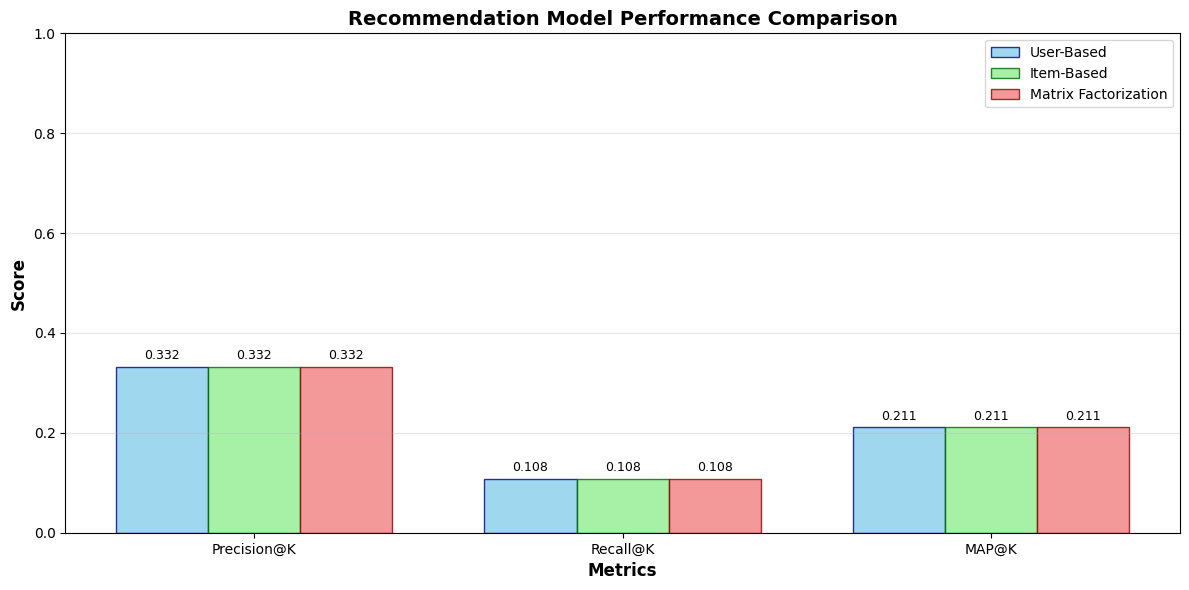

In [12]:
# CELL 12: VISUALIZE MODEL COMPARISON

def plot_model_comparison(user_results, item_results, mf_results):
    """
    Plot comparison of different models
    """
    models = ['User-Based', 'Item-Based', 'Matrix Factorization']
    metrics = ['Precision@K', 'Recall@K', 'MAP@K']
    
    # Prepare data
    data = {
        'User-Based': [user_results[m] for m in metrics],
        'Item-Based': [item_results[m] for m in metrics],
        'Matrix Factorization': [mf_results[m] for m in metrics]
    }
    
    # Create plot
    fig, ax = plt.subplots(figsize=(12, 6))
    
    x = np.arange(len(metrics))
    width = 0.25
    
    bars1 = ax.bar(x - width, data['User-Based'], width, label='User-Based', 
                   alpha=0.8, color='skyblue', edgecolor='navy')
    bars2 = ax.bar(x, data['Item-Based'], width, label='Item-Based', 
                   alpha=0.8, color='lightgreen', edgecolor='darkgreen')
    bars3 = ax.bar(x + width, data['Matrix Factorization'], width, 
                   label='Matrix Factorization', alpha=0.8, color='lightcoral', 
                   edgecolor='darkred')
    
    ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
    ax.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax.set_title('Recommendation Model Performance Comparison', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.legend(loc='upper right')
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()

# Plot comparison
if 'user_results' in locals() and 'item_results' in locals() and 'mf_results' in locals():
    plot_model_comparison(user_results, item_results, mf_results)

In [13]:
# CELL 13: GENERATE RECOMMENDATIONS FOR SAMPLE USER

def get_movie_titles(movie_ids, movies_df):
    """
    Get movie titles from movie IDs
    """
    titles = []
    for movie_id in movie_ids:
        title = movies_df[movies_df['movie_id'] == movie_id]['title'].values
        if len(title) > 0:
            titles.append(title[0])
        else:
            titles.append(f"Movie {movie_id}")
    return titles

if user_item_matrix is not None and movies is not None:
    # Choose a sample user
    sample_user = test_users[0]
    print(f"\n" + "="*60)
    print(f"RECOMMENDATIONS FOR USER {sample_user}")
    print("="*60)
    
    # Get movies the user has already rated highly
    user_ratings = user_item_matrix.loc[sample_user]
    highly_rated = user_ratings[user_ratings >= 4].index[:5]
    highly_rated_titles = get_movie_titles(highly_rated, movies)
    
    print("\n📽️ Movies this user rated highly (4+ stars):")
    print("-" * 40)
    for i, title in enumerate(highly_rated_titles, 1):
        print(f"  {i}. {title}")
    
    # Get recommendations from each model
    print("\n" + "="*60)
    print("TOP 10 RECOMMENDATIONS FROM DIFFERENT MODELS")
    print("="*60)
    
    # User-based recommendations
    print("\n🔵 User-Based Collaborative Filtering:")
    print("-" * 40)
    user_recs = user_based_cf.recommend_movies(sample_user, n_recommendations=10)
    user_titles = get_movie_titles(user_recs['movie_id'].tolist(), movies)
    for i, (title, rating) in enumerate(zip(user_titles, user_recs['predicted_rating']), 1):
        print(f"  {i}. {title[:60]}... (Predicted: {rating:.2f})")
    
    # Item-based recommendations
    print("\n🟢 Item-Based Collaborative Filtering:")
    print("-" * 40)
    item_recs = item_based_cf.recommend_movies(sample_user, n_recommendations=10)
    item_titles = get_movie_titles(item_recs['movie_id'].tolist(), movies)
    for i, (title, rating) in enumerate(zip(item_titles, item_recs['predicted_rating']), 1):
        print(f"  {i}. {title[:60]}... (Predicted: {rating:.2f})")
    
    # Matrix Factorization recommendations
    print("\n🔴 Matrix Factorization (SVD):")
    print("-" * 40)
    mf_recs = mf_recommender.recommend_movies(sample_user, n_recommendations=10)
    mf_titles = get_movie_titles(mf_recs['movie_id'].tolist(), movies)
    for i, (title, rating) in enumerate(zip(mf_titles, mf_recs['predicted_rating']), 1):
        print(f"  {i}. {title[:60]}... (Predicted: {rating:.2f})")


RECOMMENDATIONS FOR USER 97

📽️ Movies this user rated highly (4+ stars):
----------------------------------------
  1. Toy Story (1995)
  2. Twelve Monkeys (1995)
  3. Taxi Driver (1976)
  4. Apollo 13 (1995)
  5. Crumb (1994)

TOP 10 RECOMMENDATIONS FROM DIFFERENT MODELS

🔵 User-Based Collaborative Filtering:
----------------------------------------
  1. Star Wars (1977)... (Predicted: 2.69)
  2. Fargo (1996)... (Predicted: 2.25)
  3. Return of the Jedi (1983)... (Predicted: 2.18)
  4. Contact (1997)... (Predicted: 2.06)
  5. Raiders of the Lost Ark (1981)... (Predicted: 1.91)
  6. English Patient, The (1996)... (Predicted: 1.87)
  7. Toy Story (1995)... (Predicted: 1.85)
  8. Godfather, The (1972)... (Predicted: 1.84)
  9. Silence of the Lambs, The (1991)... (Predicted: 1.82)
  10. Scream (1996)... (Predicted: 1.72)

🟢 Item-Based Collaborative Filtering:
----------------------------------------
  1. Star Wars (1977)... (Predicted: 2.69)
  2. Fargo (1996)... (Predicted: 2.25)
  3. R

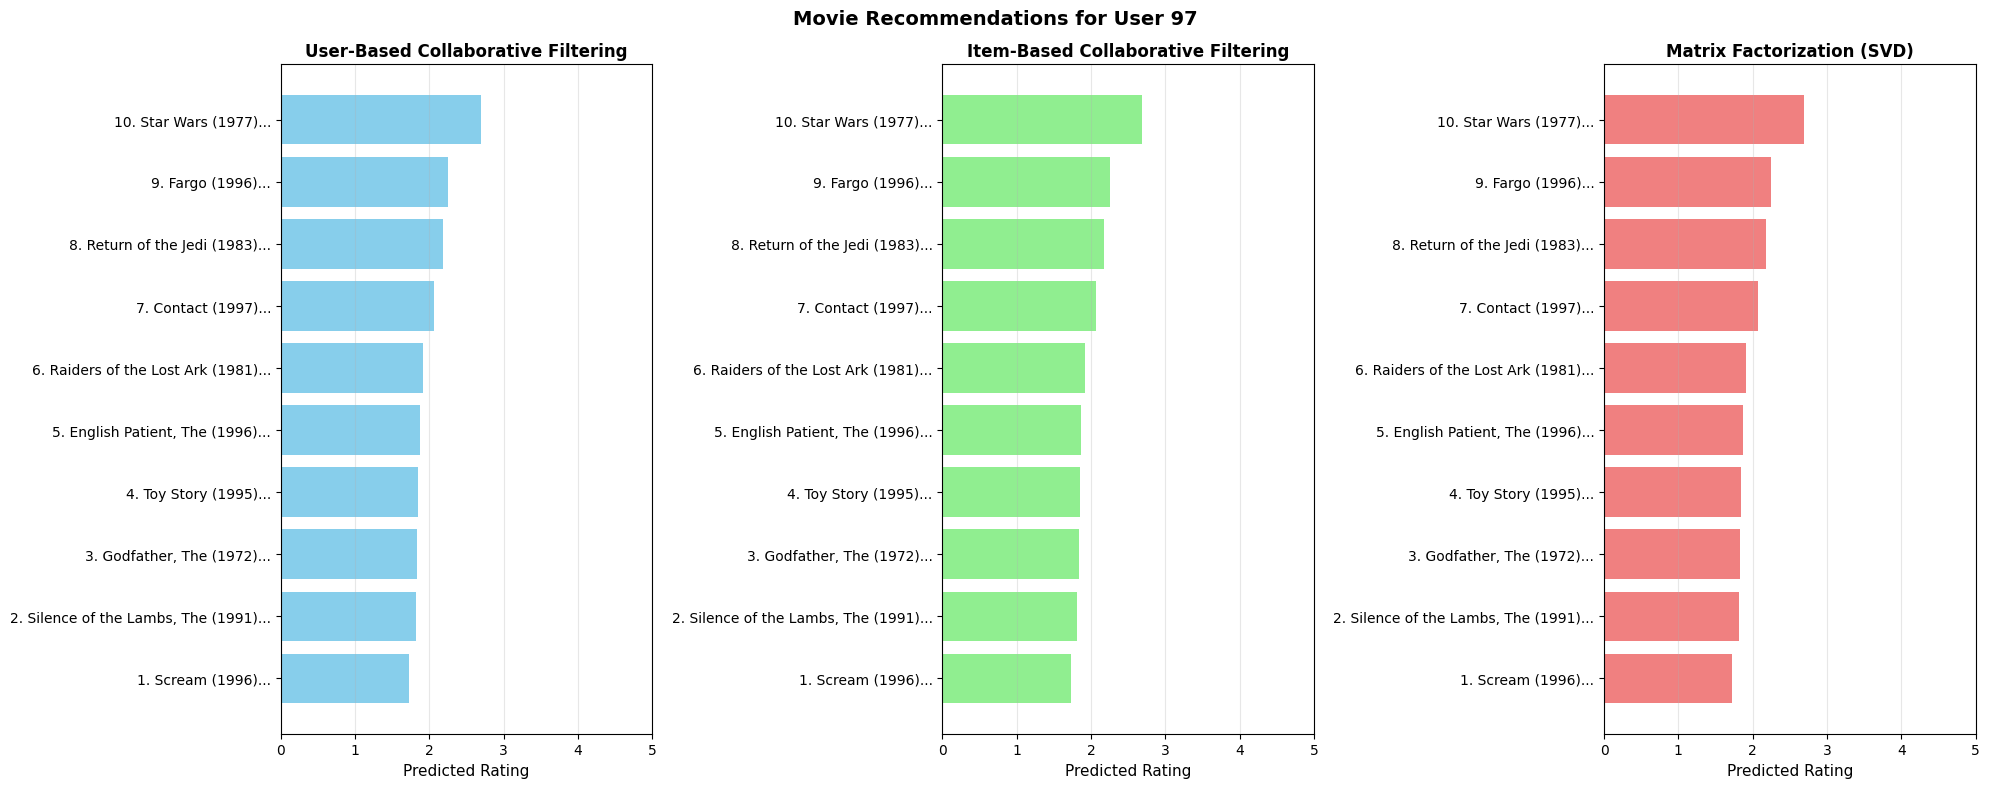

In [14]:
# CELL 14: VISUALIZE RECOMMENDATIONS

def visualize_user_recommendations(user_id, user_recs, item_recs, mf_recs, movies_df):
    """
    Visualize recommendations from different models
    """
    fig, axes = plt.subplots(1, 3, figsize=(20, 8))
    
    # Get movie titles
    user_titles = get_movie_titles(user_recs['movie_id'].tolist(), movies_df)
    item_titles = get_movie_titles(item_recs['movie_id'].tolist(), movies_df)
    mf_titles = get_movie_titles(mf_recs['movie_id'].tolist(), movies_df)
    
    # Colors for each model
    colors = ['skyblue', 'lightgreen', 'lightcoral']
    
    # User-based
    y_pos = np.arange(10)
    axes[0].barh(y_pos, user_recs['predicted_rating'][::-1], color=colors[0])
    axes[0].set_yticks(y_pos)
    axes[0].set_yticklabels([f"{i+1}. {t[:40]}..." for i, t in enumerate(user_titles[::-1])])
    axes[0].set_xlabel('Predicted Rating', fontsize=11)
    axes[0].set_title('User-Based Collaborative Filtering', fontsize=12, fontweight='bold')
    axes[0].set_xlim(0, 5)
    axes[0].grid(True, alpha=0.3, axis='x')
    
    # Item-based
    axes[1].barh(y_pos, item_recs['predicted_rating'][::-1], color=colors[1])
    axes[1].set_yticks(y_pos)
    axes[1].set_yticklabels([f"{i+1}. {t[:40]}..." for i, t in enumerate(item_titles[::-1])])
    axes[1].set_xlabel('Predicted Rating', fontsize=11)
    axes[1].set_title('Item-Based Collaborative Filtering', fontsize=12, fontweight='bold')
    axes[1].set_xlim(0, 5)
    axes[1].grid(True, alpha=0.3, axis='x')
    
    # Matrix Factorization
    axes[2].barh(y_pos, mf_recs['predicted_rating'][::-1], color=colors[2])
    axes[2].set_yticks(y_pos)
    axes[2].set_yticklabels([f"{i+1}. {t[:40]}..." for i, t in enumerate(mf_titles[::-1])])
    axes[2].set_xlabel('Predicted Rating', fontsize=11)
    axes[2].set_title('Matrix Factorization (SVD)', fontsize=12, fontweight='bold')
    axes[2].set_xlim(0, 5)
    axes[2].grid(True, alpha=0.3, axis='x')
    
    plt.suptitle(f'Movie Recommendations for User {user_id}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Then call the function (add this after Cell 13)
if 'user_recs' in locals() and 'item_recs' in locals() and 'mf_recs' in locals():
    visualize_user_recommendations(sample_user, user_recs, item_recs, mf_recs, movies)

In [15]:
# CELL 15: SAVE RESULTS

# Save recommendations to CSV
if 'user_recs' in locals():
    # Add movie titles to recommendations
    user_recs_with_titles = user_recs.copy()
    user_recs_with_titles['title'] = get_movie_titles(user_recs['movie_id'].tolist(), movies)
    user_recs_with_titles.to_csv('user_based_recommendations.csv', index=False)
    print(" Saved user-based recommendations to CSV")
    
    item_recs_with_titles = item_recs.copy()
    item_recs_with_titles['title'] = get_movie_titles(item_recs['movie_id'].tolist(), movies)
    item_recs_with_titles.to_csv('item_based_recommendations.csv', index=False)
    print(" Saved item-based recommendations to CSV")
    
    mf_recs_with_titles = mf_recs.copy()
    mf_recs_with_titles['title'] = get_movie_titles(mf_recs['movie_id'].tolist(), movies)
    mf_recs_with_titles.to_csv('matrix_factorization_recommendations.csv', index=False)
    print(" Saved matrix factorization recommendations to CSV")

 Saved user-based recommendations to CSV
 Saved item-based recommendations to CSV
 Saved matrix factorization recommendations to CSV
